# 00 - Exploration
Setup only: paths, data index, sample grid, and lazy loaders for the RAR and VAR autoencoders.
Long jobs and feature extraction belong in scripts (tmux), with outputs cached to disk.

In [1]:
import os, sys, gc
# Hugging Face cache on the persistent volume (only /workspace survives a pod restart).
os.environ["HF_HOME"] = "/workspace/hf_cache"

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image

# Same paths and label order as tracer/common.py.
DATA = Path("/workspace/data")
WEIGHTS = Path("/workspace/weights")
EXTERNAL = Path("/workspace/external")
CACHE = Path("/workspace/cache")  # cached outputs, outside the repo
CACHE.mkdir(exist_ok=True)

LABELS = ["var16", "var20", "var24", "var30", "rarb", "rarl", "rarxl", "rarxxl", "outlier"]
DEVICE = "cuda"
print(torch.__version__, torch.cuda.get_device_name(0))

2.6.0+cu124 NVIDIA A40


## Data index

In [2]:
# One row per image. train/val labels come from the class folder name; test images are unlabeled.
rows = []
for split in ["train", "val"]:
    for p in sorted((DATA / split).glob("*/*.png")):
        rows.append((split, p.parent.name, p.name, str(p)))
for p in sorted((DATA / "test").glob("*.png"), key=lambda q: int(q.stem)):  # numeric order: 1, 2, ..., 9800
    rows.append(("test", None, p.name, str(p)))
df = pd.DataFrame(rows, columns=["split", "label", "name", "path"])

# Images per split, and per label x split for the labeled splits.
print(df.groupby("split").size())
df[df.split != "test"].pivot_table(index="label", columns="split", values="name", aggfunc="count")

split
test     9800
train     800
val       450
dtype: int64


split,train,val
label,,
outlier,NaN,50.0
rarb,100.0,50.0
rarl,100.0,50.0
rarxl,100.0,50.0
rarxxl,100.0,50.0
var16,100.0,50.0
var20,100.0,50.0
var24,100.0,50.0
var30,100.0,50.0


(256, 256)


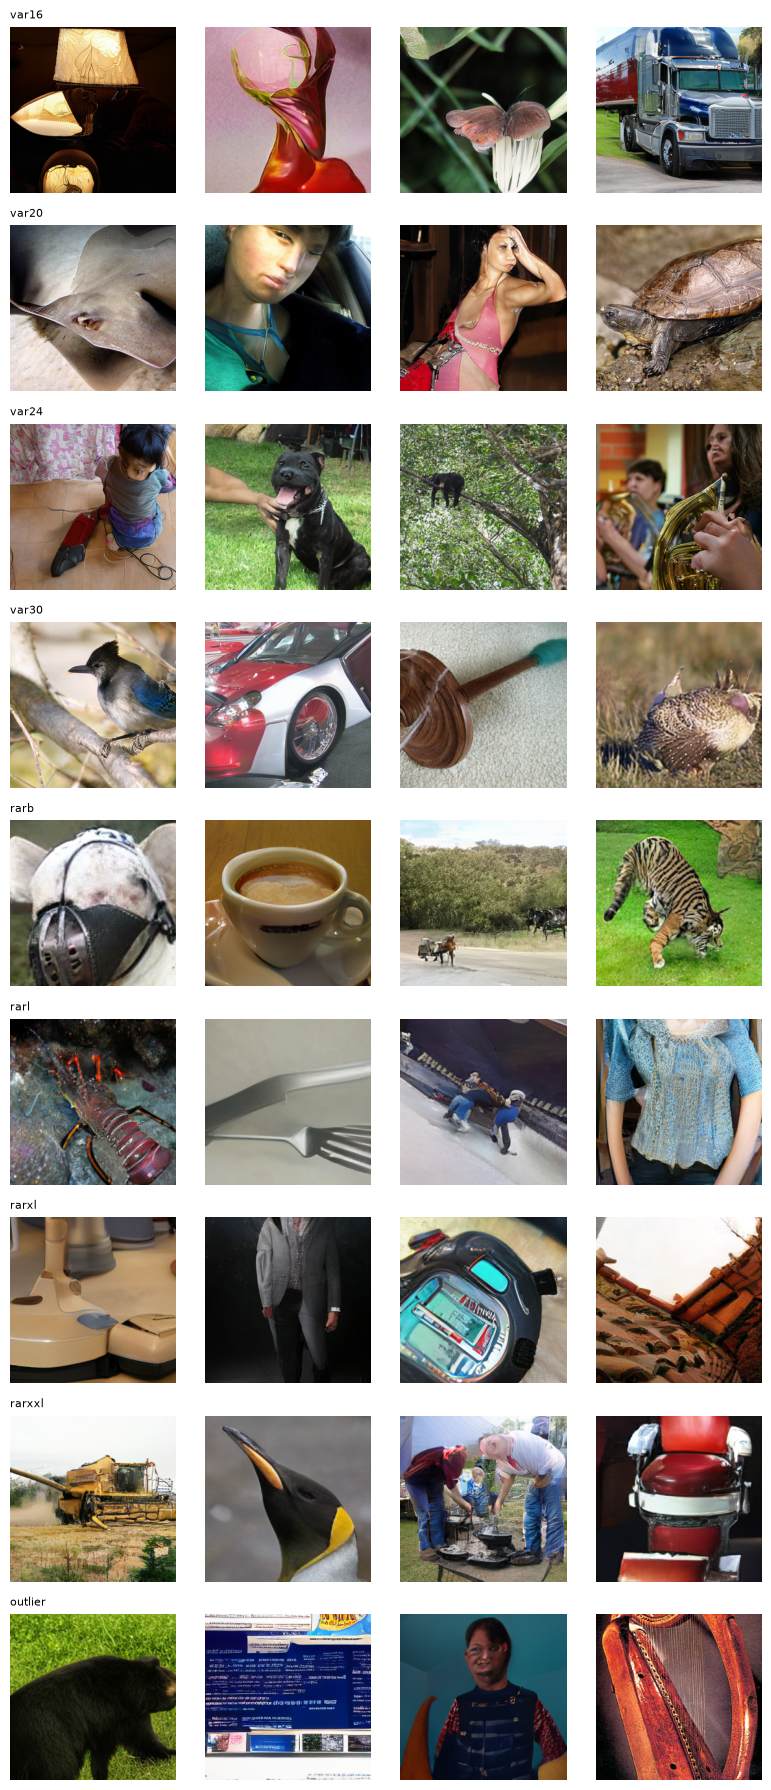

In [3]:
def load_img(path):
    return Image.open(path).convert("RGB")

def to_tensor(img):
    """PIL -> [1,3,H,W] float in [0,1] on DEVICE."""
    return torch.from_numpy(np.array(img)).permute(2, 0, 1)[None].float().div(255).to(DEVICE)

def show_grid(split="train", n=4, seed=0):
    """Plot n random images per label (one row per label present in the split)."""
    labs = [l for l in LABELS if (df[(df.split == split) & (df.label == l)].shape[0])]
    fig, axs = plt.subplots(len(labs), n, figsize=(2 * n, 2 * len(labs)))
    for i, l in enumerate(labs):
        sub = df[(df.split == split) & (df.label == l)].sample(n, random_state=seed)
        for j, p in enumerate(sub.path):
            axs[i, j].imshow(load_img(p)); axs[i, j].axis("off")
        axs[i, 0].set_title(l, fontsize=8, loc="left")
    plt.tight_layout(); plt.show()

print(load_img(df.path[0]).size)  # image resolution
show_grid("val")

## Model loaders
Both repos expose top-level packages named `models`, `utils`, `data`, so only one can be imported at a time.
Loaders put the right repo on `sys.path` and clear conflicting modules. Call `free()` when switching.

In [4]:
# Exploration versions of the loaders; tracer/common.py has the maintained ones used by the scripts.
# Top-level module names shared by the two external repos.
CLASHING = ("models", "utils", "data", "modeling")

def _switch_repo(path):
    """Make `path` the only external repo on sys.path and drop cached modules whose names clash."""
    for p in [str(EXTERNAL / "VAR"), str(EXTERNAL / "1d-tokenizer")]:
        while p in sys.path:
            sys.path.remove(p)
    for m in [k for k in sys.modules if k.split(".")[0] in CLASHING]:
        del sys.modules[m]
    sys.path.insert(0, str(path))

def free():
    """Release GPU memory after `del`-ing a model."""
    gc.collect(); torch.cuda.empty_cache()

def load_rar_tokenizer():
    """RAR MaskGIT-VQ tokenizer. encode: [B,3,256,256] in [0,1] -> codes; decode: codes -> [0,1] image."""
    _switch_repo(EXTERNAL / "1d-tokenizer")
    from modeling.titok import PretrainedTokenizer
    return PretrainedTokenizer(str(WEIGHTS / "rar/maskgit-vqgan-imagenet-f16-256.bin")).to(DEVICE).eval()

def load_var_vae():
    """VAR multi-scale VQVAE. Use img_to_idxBl / idxBl_to_img (inputs in [-1,1]); vae(x) needs torch.distributed."""
    _switch_repo(EXTERNAL / "VAR")
    from models import build_vae_var
    # Builds the VAE together with a d16 VAR transformer; only the VAE is kept.
    vae, _ = build_vae_var(device=DEVICE, depth=16, flash_if_available=False, fused_if_available=False)
    vae.load_state_dict(torch.load(WEIGHTS / "var/vae_ch160v4096z32.pth", map_location="cpu"), strict=True)
    return vae.eval().requires_grad_(False)

attention mode is flash


/workspace/external/1d-tokenizer/modeling/modules/losses.py:141: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/workspace/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/workspace/external/1d-tokenizer/modeling/quantizer/quantizer.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/workspace/external/1d-tokenizer/modeling/quantizer/quantizer.py:134: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/workspace/external/1d-tokenizer/modeling/quantizer/quantizer.py:154: FutureWarning: `torch.cuda


[constructor]  ==== flash_if_available=False (0/16), fused_if_available=False (fusing_add_ln=0/16, fusing_mlp=0/16) ==== 
    [VAR config ] embed_dim=1024, num_heads=16, depth=16, mlp_ratio=4.0
    [drop ratios ] drop_rate=0.0, attn_drop_rate=0.0, drop_path_rate=0.0666667 (tensor([0.0000, 0.0044, 0.0089, 0.0133, 0.0178, 0.0222, 0.0267, 0.0311, 0.0356,
        0.0400, 0.0444, 0.0489, 0.0533, 0.0578, 0.0622, 0.0667]))

[init_weights] VAR with init_std=0.0180422


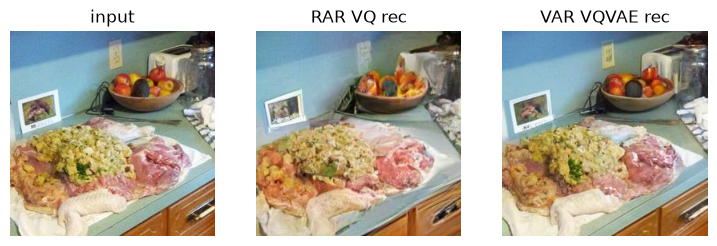

In [5]:
# Sanity check: round-trip one val image through each autoencoder
x = to_tensor(load_img(df[df.split == "val"].path.iloc[0]))

with torch.no_grad():
    # RAR: image -> 16x16 token grid -> image. Free the model before loading the next one.
    rar_tok = load_rar_tokenizer()
    rar_rec = rar_tok.decode(rar_tok.encode(x))
    del rar_tok; free()

    # VAR: map [0,1] -> [-1,1], image -> multi-scale tokens -> image (last scale only), back to [0,1].
    vae = load_var_vae()
    var_rec = ((vae.idxBl_to_img(vae.img_to_idxBl(x * 2 - 1), same_shape=True, last_one=True) + 1) / 2).clamp(0, 1)
    del vae; free()

# Input next to both reconstructions.
fig, axs = plt.subplots(1, 3, figsize=(9, 3))
for a, im, t in zip(axs, [x, rar_rec, var_rec], ["input", "RAR VQ rec", "VAR VQVAE rec"]):
    a.imshow(im[0].permute(1, 2, 0).cpu().numpy()); a.set_title(t); a.axis("off")
plt.show()